# Bayesian Regression - Housing Demo

In [2]:
import numpy as np
import pandas as pd
import scipy.stats as st
import matplotlib.pyplot as plt


df = pd.read_csv("../Data/housing.csv")

df = df.copy()
df["price"] = pd.to_numeric(df["price"], errors="coerce")
df = df.dropna()

df["log_price"] = np.log(df["price"])

yn_cols = ["fireplace", "basement", "central_air"]
for c in yn_cols:
    df[c] = df[c].astype(str).str.strip().str.lower().map({"yes": 1, "no": 0})

df["furnishingstatus"] = df["furnishingstatus"].astype(str).str.strip().str.lower()
dummies = pd.get_dummies(df["furnishingstatus"], prefix="furnish", drop_first=True)

num_cols = ["area", "bedrooms", "bathrooms", "stories", "covered_parking_spaces"]
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df = df.dropna(subset=num_cols + yn_cols + ["log_price"])

X_df = pd.concat(
    [
        df[num_cols],
        df[yn_cols],
        dummies
    ],
    axis=1
)

y = df["log_price"].to_numpy()
feature_names = X_df.columns.tolist()

#Standardize numeric predictors (so priors make sense)
X = X_df.to_numpy().astype(float)
X_means = X.mean(axis=0)
X_stds = X.std(axis=0, ddof=0)
#Only standardize the truly continuous-ish numeric ones; leave 0/1 dummies alone
standardize_mask = np.array([name in num_cols for name in feature_names], dtype=bool)
X[:, standardize_mask] = (X[:, standardize_mask] - X_means[standardize_mask]) / X_stds[standardize_mask]

X = np.column_stack([np.ones(len(X)), X])
feature_names = ["Intercept"] + feature_names

n, p = X.shape

In [3]:
#Conjugate Bayesian Linear Regression
#    beta | sigma^2 ~ N(b0, sigma^2 * V0)
#    sigma^2 ~ Inv-Gamma(a0, d0)

def bayes_conjugate_posterior(X, y, b0, V0, a0, d0):
    V0_inv = np.linalg.inv(V0)
    XtX = X.T @ X
    Xty = X.T @ y

    Vn = np.linalg.inv(V0_inv + XtX)
    bn = Vn @ (V0_inv @ b0 + Xty)
    an = a0 + X.shape[0] / 2.0

    yTy = float(y @ y)
    b0_quad = float(b0 @ V0_inv @ b0)
    bn_quad = float(bn @ np.linalg.inv(Vn) @ bn)
    dn = d0 + 0.5 * (yTy + b0_quad - bn_quad)

    return bn, Vn, an, dn

def sample_posterior(bn, Vn, an, dn, draws=8000, seed=42):
    rng = np.random.default_rng(seed)
    # Inv-Gamma sampling via Gamma on precision
    sigma2 = 1.0 / rng.gamma(shape=an, scale=1.0 / dn, size=draws)
    L = np.linalg.cholesky(Vn)
    z = rng.normal(size=(draws, bn.size))
    beta = bn + (np.sqrt(sigma2)[:, None] * (z @ L.T))
    return beta, sigma2

def et_ci(samples, level=0.95):
    lo = (1 - level) / 2
    hi = 1 - lo
    return np.quantile(samples, [lo, hi])

#Weakly informative prior:
#Since predictors are standardized, N(0, 1^2) or N(0, 2^2) on slopes is reasonable.
b0 = np.zeros(p)
V0 = np.diag([10.0**2] + [2.0**2] * (p - 1))  # loose intercept, moderate slopes

#sigma^2 prior (Inv-Gamma). Keep weak-ish.
a0, d0 = 2.0, 1.0

bn, Vn, an, dn = bayes_conjugate_posterior(X, y, b0, V0, a0, d0)
beta_samps, sigma2_samps = sample_posterior(bn, Vn, an, dn, draws=12000, seed=7)
sigma_samps = np.sqrt(sigma2_samps)

In [4]:
#Summaries (coefficients and intervals)

beta_means = beta_samps.mean(axis=0)
beta_ci = np.array([et_ci(beta_samps[:, j], 0.95) for j in range(p)])

summary = pd.DataFrame({
    "term": feature_names,
    "post_mean": beta_means,
    "ci_2.5": beta_ci[:, 0],
    "ci_97.5": beta_ci[:, 1],
})
#Sort by absolute posterior mean (excluding intercept)
summary_no_intercept = summary[summary["term"] != "Intercept"].copy()
summary_no_intercept["abs_mean"] = summary_no_intercept["post_mean"].abs()
summary_no_intercept = summary_no_intercept.sort_values("abs_mean", ascending=False)

print("\nPosterior summary (log(price) regression)")
print(summary_no_intercept.drop(columns=["abs_mean"]).head(15).to_string(index=False))

print("\nPosterior mean sigma (on log scale):", sigma_samps.mean().round(4))

#Helpful interpretation note for standardized predictors:
#For standardized numeric predictors, a 1 SD increase in X changes log(price) by beta, which is ~100*(exp(beta)-1)% in price.
def pct_effect(beta):
    return 100 * (np.exp(beta) - 1)

top = summary_no_intercept.head(8).copy()
top["approx_%_change_for_1_unit"] = top["post_mean"].apply(pct_effect)
print("\nApprox percent change in price for 1 SD increase (numeric) or 0->1 (binary), using posterior mean:")
print(top[["term","post_mean","approx_%_change_for_1_unit"]].to_string(index=False))


Posterior summary (log(price) regression)
                  term  post_mean    ci_2.5   ci_97.5
           central_air   0.166785  0.121797  0.212293
                  area   0.127265  0.105774  0.148624
   furnish_unfurnished  -0.126107 -0.178812 -0.072962
              basement   0.117559  0.071422  0.163421
               stories   0.088945  0.065384  0.112143
             fireplace   0.080288  0.024656  0.136461
             bathrooms   0.079891  0.057569  0.101989
covered_parking_spaces   0.046127  0.024928  0.067412
              bedrooms   0.017573 -0.004795  0.039982
furnish_semi-furnished   0.011604 -0.037837  0.059935

Posterior mean sigma (on log scale): 0.2314

Approx percent change in price for 1 SD increase (numeric) or 0->1 (binary), using posterior mean:
                  term  post_mean  approx_%_change_for_1_unit
           central_air   0.166785                   18.150030
                  area   0.127265                   13.571827
   furnish_unfurnished  -0.12610

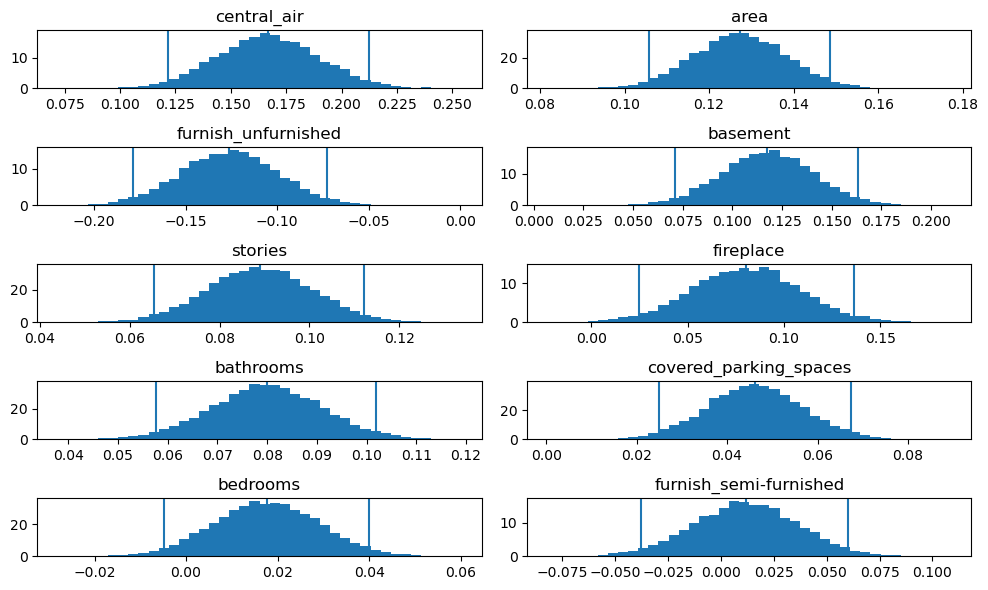

In [5]:
#Graphics: coefficient posteriors (top 10 by |mean|)
top_terms = summary_no_intercept.head(10)["term"].tolist()
idx_map = {t:i for i,t in enumerate(feature_names)}
top_idx = [idx_map[t] for t in top_terms]

plt.figure(figsize=(10, 6))
for k, j in enumerate(top_idx):
    vals = beta_samps[:, j]
    plt.subplot(5, 2, k+1)
    plt.hist(vals, bins=40, density=True)
    lo, hi = et_ci(vals, 0.95)
    plt.axvline(lo)
    plt.axvline(hi)
    plt.axvline(vals.mean())
    plt.title(top_terms[k])
plt.tight_layout()
plt.show()

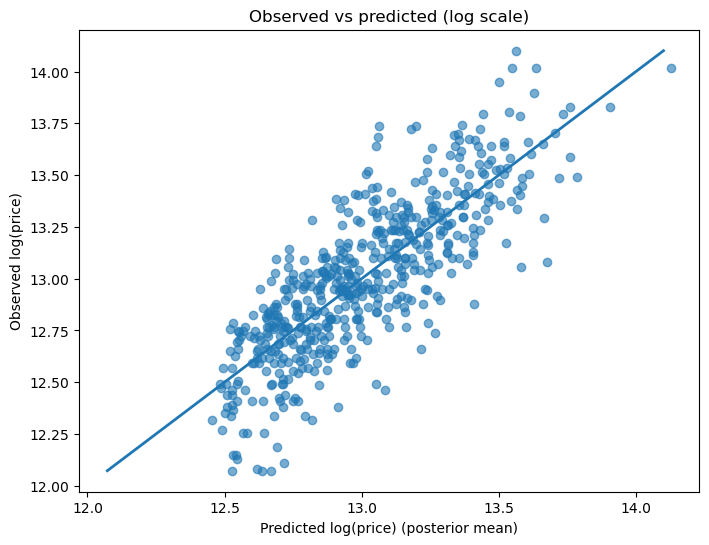

In [6]:
#Posterior predictive intervals for observations
S = 5000
rng = np.random.default_rng(123)
pick = rng.choice(beta_samps.shape[0], size=S, replace=False)
beta_sub = beta_samps[pick]
sig_sub = sigma_samps[pick]

mu_draws = beta_sub @ X.T                      # (S, n)
yrep_draws = mu_draws + rng.normal(0, sig_sub[:, None], size=mu_draws.shape)

mu_mean = mu_draws.mean(axis=0)
mu_lo, mu_hi = np.quantile(mu_draws, [0.025, 0.975], axis=0)
pr_lo, pr_hi = np.quantile(yrep_draws, [0.025, 0.975], axis=0)

#Observed vs predicted (with intervals)
plt.figure(figsize=(8, 6))
plt.scatter(mu_mean, y, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], linewidth=2)
plt.xlabel("Predicted log(price) (posterior mean)")
plt.ylabel("Observed log(price)")
plt.title("Observed vs predicted (log scale)")
plt.show()

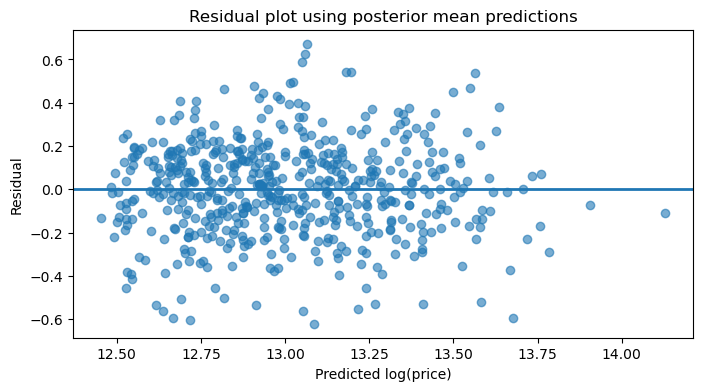

In [7]:
#Residuals using posterior mean line
resid = y - mu_mean
plt.figure(figsize=(8, 4))
plt.scatter(mu_mean, resid, alpha=0.6)
plt.axhline(0, linewidth=2)
plt.xlabel("Predicted log(price)")
plt.ylabel("Residual")
plt.title("Residual plot using posterior mean predictions")
plt.show()


Posterior predictive checks (simple stats)
PPC p-value for mean: 0.502
PPC p-value for sd:   0.773


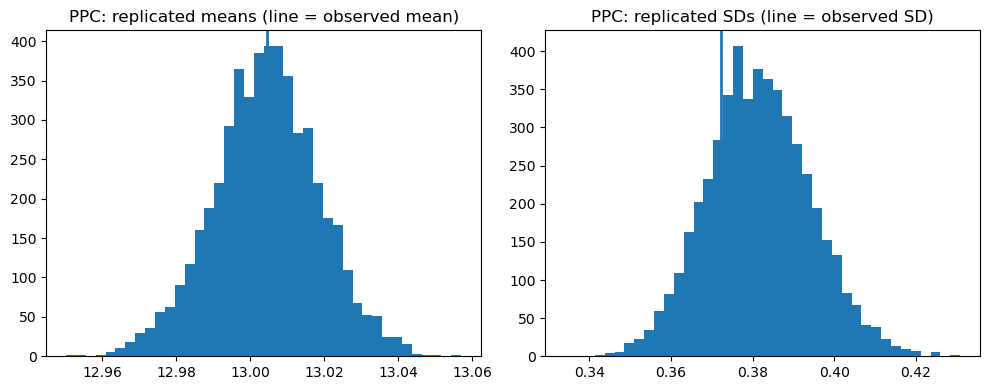

In [8]:
#Posterior predictive checks (real diagnostics for this setting)
obs_mean, obs_sd = y.mean(), y.std(ddof=1)

rep_mean = yrep_draws.mean(axis=1)
rep_sd = yrep_draws.std(axis=1, ddof=1)

pp_pval_mean = np.mean(rep_mean >= obs_mean)
pp_pval_sd = np.mean(rep_sd >= obs_sd)

print("\nPosterior predictive checks (simple stats)")
print("PPC p-value for mean:", round(pp_pval_mean, 3))
print("PPC p-value for sd:  ", round(pp_pval_sd, 3))

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(rep_mean, bins=40)
plt.axvline(obs_mean, linewidth=2)
plt.title("PPC: replicated means (line = observed mean)")

plt.subplot(1, 2, 2)
plt.hist(rep_sd, bins=40)
plt.axvline(obs_sd, linewidth=2)
plt.title("PPC: replicated SDs (line = observed SD)")
plt.tight_layout()
plt.show()


Prior sensitivity on top terms (posterior mean and 95% interval)
 prior_slope_sd                term  post_mean    ci_2.5   ci_97.5
            0.5         central_air   0.162701  0.118482  0.207233
            0.5                area   0.127102  0.106491  0.148906
            0.5 furnish_unfurnished  -0.122011 -0.174974 -0.069357
            0.5            basement   0.114633  0.069472  0.159536
            0.5             stories   0.088709  0.065834  0.111415
            0.5           fireplace   0.078932  0.023420  0.133348
            2.0         central_air   0.166772  0.122431  0.211385
            2.0                area   0.127292  0.105695  0.149199
            2.0 furnish_unfurnished  -0.126798 -0.180384 -0.072062
            2.0            basement   0.117090  0.071434  0.162945
            2.0             stories   0.088846  0.065787  0.111616
            2.0           fireplace   0.079804  0.025427  0.136077
            5.0         central_air   0.166543  0.120950  0.211

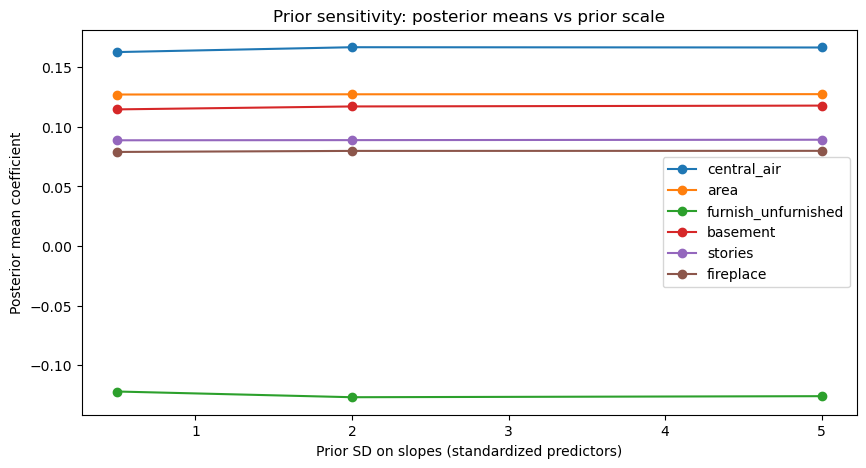

In [9]:
#Prior sensitivity (quick, honest, and teachable)
#Try 3 different slope prior scales and show how top coefficients move.
prior_scales = [0.5, 2.0, 5.0]  #tighter -> more shrinkage
sens_rows = []

for sscale in prior_scales:
    V0_s = np.diag([10.0**2] + [sscale**2] * (p - 1))
    bn_s, Vn_s, an_s, dn_s = bayes_conjugate_posterior(X, y, b0, V0_s, a0, d0)
    beta_s, _ = sample_posterior(bn_s, Vn_s, an_s, dn_s, draws=6000, seed=int(100*sscale)+3)
    for t in top_terms[:6]:
        j = idx_map[t]
        sens_rows.append({
            "prior_slope_sd": sscale,
            "term": t,
            "post_mean": beta_s[:, j].mean(),
            "ci_2.5": np.quantile(beta_s[:, j], 0.025),
            "ci_97.5": np.quantile(beta_s[:, j], 0.975),
        })

sens = pd.DataFrame(sens_rows)
print("\nPrior sensitivity on top terms (posterior mean and 95% interval)")
print(sens.to_string(index=False))

#Small plot: how posterior mean changes with prior
plt.figure(figsize=(10, 5))
for t in top_terms[:6]:
    sub = sens[sens["term"] == t].sort_values("prior_slope_sd")
    plt.plot(sub["prior_slope_sd"], sub["post_mean"], marker="o", label=t)
plt.xlabel("Prior SD on slopes (standardized predictors)")
plt.ylabel("Posterior mean coefficient")
plt.title("Prior sensitivity: posterior means vs prior scale")
plt.legend()
plt.show()